<a href="https://colab.research.google.com/github/DayaRodriguezM/MercadoLibre-Funnel-Analysis-SQL/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:

#importar libreria
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [ ]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("=== ANÁLISIS DE NULOS EN USERS ===")
total_users = len(users)
for col in users.columns:
    nulos = users[col].isna().sum()
    porcentaje = (nulos / total_users) * 100
    print(f"{col}: {nulos} nulos ({porcentaje:.1f}%)")


=== ANÁLISIS DE NULOS EN USERS ===
user_id: 0 nulos (0.0%)
first_name: 0 nulos (0.0%)
last_name: 0 nulos (0.0%)
age: 0 nulos (0.0%)
city: 469 nulos (11.7%)
reg_date: 0 nulos (0.0%)
plan: 0 nulos (0.0%)
churn_date: 3534 nulos (88.3%)


In [ ]:
# cantidad de nulos para usage
print("\n=== ANÁLISIS DE NULOS EN USAGE ===")
total_usage = len(usage)
for col in usage.columns:
    nulos = usage[col].isna().sum()
    porcentaje = (nulos / total_usage) * 100
    print(f"{col}: {nulos} nulos ({porcentaje:.1f}%)")



=== ANÁLISIS DE NULOS EN USAGE ===
id: 0 nulos (0.0%)
user_id: 0 nulos (0.0%)
type: 0 nulos (0.0%)
date: 50 nulos (0.1%)
duration: 22076 nulos (55.2%)
length: 17896 nulos (44.7%)


In [ ]:
# Verificar el total de registros
print(f"Total de registros en USERS: {len(users)}")
print(f"Registros con plan no nulo: {users['plan'].notna().sum()}")
print(f"\nValores únicos en city: {users['city'].nunique()}")
print(users['city'].value_counts())
print(f"Registros con churn_date nulo (usuarios activos): {users['churn_date'].isna().sum()}")
print(f"Registros con churn_date no nulo (usuarios que hicieron churn): {users['churn_date'].notna().sum()}")

Total de registros en USERS: 4000
Registros con plan no nulo: 4000

Valores únicos en city: 7
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Registros con churn_date nulo (usuarios activos): 3534
Registros con churn_date no nulo (usuarios que hicieron churn): 466


In [ ]:
# Ver distribución de planes en clientes con churn_date NaN
active_customers_plans = users[users['churn_date'].isna()]['plan'].value_counts()
print("Planes de clientes activos (churn_date NaN):")
print(active_customers_plans)

Planes de clientes activos (churn_date NaN):
Basico     2297
Premium    1237
Name: plan, dtype: int64


In [ ]:
# Verificar el total de registros
print(f"Total de registros en USAGE: {len(usage)}")
print(f"Registros con tipo no nulo: {usage['type'].notna().sum()}")
print(f"\nValores únicos en duration: {usage['duration'].nunique()}")
print(f"\nValores únicos en length: {usage['length'].nunique()}")

# Verificar si las llamadas tienen NaN en length
calls_with_length = usage[usage['type'] == 'call']['length'].notna().sum()
print(f"Llamadas con valores en length: {calls_with_length}")

# Verificar si los textos tienen NaN en duration
texts_with_duration = usage[usage['type'] == 'text']['duration'].notna().sum()
print(f"Textos con valores en duration: {texts_with_duration}")

Total de registros en USAGE: 40000
Registros con tipo no nulo: 40000

Valores únicos en duration: 2090

Valores únicos en length: 123
Llamadas con valores en length: 12
Textos con valores en duration: 16


In [ ]:
# Ver ejemplos de registros problemáticos
print("Llamadas con length:")
print(usage[(usage['type'] == 'call') & (usage['length'].notna())][['type', 'duration', 'length']].head())

print("\nTextos con duration:")
print(usage[(usage['type'] == 'text') & (usage['duration'].notna())][['type', 'duration', 'length']].head())


Llamadas con length:
       type  duration  length
2070   call      1.68  1490.0
5272   call      3.78  1490.0
10614  call      0.53  1490.0
12692  call      1.80  1490.0
16910  call      3.29  1490.0

Textos con duration:
       type  duration  length
1414   text     120.0    65.0
1824   text     120.0    40.0
1932   text     120.0    69.0
2972   text     120.0    68.0
11456  text     120.0    23.0


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 **Diagnóstico:**
 - DataFrame Users y Usage presentan columnas con valores faltantes y que se debe estandarizar el tipo de formato
   

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
   - DF USERS:
     - Columna 'city' tiene 11,7% de valores nulos por lo que se debe convertir a NaN.
     - Columna 'churn_date' tiene el 88,3% de los datos con NaN por lo cual se mantiene tal como esta.
     - Columna 'reg_date' convertir a tipo datetime.
   - DF USAGE:
     - Columna 'duration' tiene 55,2% de valores vacios, es de tipo MAR por lo que depende de otra variable en este caso la columna 'type'. Sin embargo, tiene 12 valores que seran eliminados por inconsistencia con 'lenght'.
     - Columna 'lenght' tiene 44,7% de valores vacios, es de tipo MAR por lo que depende de otra variable en este caso la columna 'type'. Sin embargo, tiene 16 valores que seran eliminados por inconsistencia con 'duration'.
     - Columna 'date' tiene el 0,1% de datos vacios, por lo que se eliminara y el resto de los datos se debe convertir a tipo datetime.
     
- Indica qué harías: ¿imputar, eliminar, ignorar?
 - Eliminar registros inconsistentes
 - Imputar datos faltantes en 'city'
 - Ignorar la columna 'reg_date'

  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print('Resumen estadistico de user_id:')
users['user_id'].describe()

Resumen estadistico de user_id:


count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

In [ ]:
print('Resumen estadistico de age:')
users['age'].describe()

Resumen estadistico de age:


count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

- La columna `user_id`: contiene 4.000 registros únicos, lo que indica que no existen valores duplicados ni faltantes.
Al tratarse de un identificador, no se realiza un análisis estadístico de tendencia central o distribución, ya que no aporta información relevante para el comportamiento del usuario.
- La columna `age`: cuenta con 4.000 observaciones válidas. La edad mediana es de 47 años, mientras que el promedio es de 33 años, lo que sugiere la presencia de valores atípicos en edades más bajas que están afectando el valor medio.
Esta diferencia entre media y mediana indica una distribución sesgada, por lo que la mediana representa mejor la edad típica de los usuarios que el promedio.

In [ ]:
# Verificar cantidad de valores sentinel
print(f"Registros con age = -999: {(users['age'] == -999).sum()}")
print(f"Porcentaje del total: {(users['age'] == -999).mean() * 100:.2f}%")

Registros con age = -999: 55
Porcentaje del total: 1.38%


In [ ]:
# explorar columnas numéricas de usage
print('Resumen estadistico de id:')
usage['id'].describe()

Resumen estadistico de id:


count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

In [ ]:
print('Resumen estadistico de user_id:')
usage['user_id'].describe()

Resumen estadistico de user_id:


count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

In [ ]:
print('Resumen estadistico de duration:')
usage['duration'].describe()

Resumen estadistico de duration:


count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

In [ ]:
print('Resumen estadistico de length:')
usage['length'].describe()

Resumen estadistico de length:


count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64

- Las columnas `id` y `user_id`: acontienen 40.000 registros cada una, sin valores faltantes ni duplicados, lo que garantiza la integridad de los identificadores.
Dado que ambas variables cumplen exclusivamente una función de identificación, no se realiza un análisis de distribución o medidas de tendencia central, ya que no aportan información relevante para el análisis del comportamiento de uso.
- La columna `duration` presenta un total de 17.924 registros correspondientes a la duración de las llamadas. La mediana es de 3,5 minutos, mientras que el promedio asciende a 5,20 minutos.
Esta diferencia se explica por la presencia de valores atípicos, con duraciones que alcanzan hasta 120 minutos, lo que genera una distribución sesgada a la derecha.
En este contexto, la mediana resulta una medida más representativa de la duración típica de las llamadas.
- La columna `length` cuenta con 22.104 registros que representan la longitud de los mensajes. La mediana es de 50 caracteres, mientras que el promedio es de 52 caracteres.
Aunque ambas medidas son cercanas, la presencia de valores extremos —con un máximo de 1.490 caracteres— introduce un sesgo a la derecha en la distribución.
A pesar de este sesgo, la mediana continúa reflejando adecuadamente la longitud típica de los mensajes enviados.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

In [ ]:
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` contiene 7 ciudades únicas. Bogotá es la ciudad con mayor frecuencia, concentrando 808 registros sobre un total de 3.531 usuarios.
Esta concentración sugiere una mayor presencia de clientes en dicha ciudad, lo que podría influir en los patrones de uso y debe considerarse en análisis comparativos por ubicación geográfica.
- La columna `plan` contiene 4.000 registros y presenta únicamente 2 categorías: Básico y Premium. El plan Básico es el más frecuente, con 2.595 usuarios, lo que representa la mayoría de la base.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [ ]:
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` presenta dos tipos de eventos: mensajes de texto y llamadas. Los mensajes de texto son el tipo de uso predominante, con 22.092 registros (aproximadamente el 55%), mientras que las llamadas representan 17.908 registros (alrededor del 45%).
Esta distribución indica una ligera preferencia por la comunicación vía mensajes frente a llamadas, lo que sugiere patrones de uso orientados a interacciones breves y asincrónicas.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  - La columna `age` presenta valores inválidos representados por la edad -999, los cuales no son consistentes con edades reales y corresponden a un valor de relleno.
  - La columna `city` contiene valores sentinel representados por el símbolo "?", utilizados para indicar información faltante o desconocida.
- ¿Qué acción tomarías?
   - Para los valores inválidos en la columna `age`, se opta por reemplazarlos utilizando la mediana de la columna, dado que esta medida es robusta frente a valores atípicos y representa de mejor forma la edad típica de los usuarios.
   - En el caso de los sentinels identificados en la columna `city`, estos serán imputados como NaN, permitiendo un manejo adecuado de los valores faltantes en análisis posteriores y evitando interpretaciones erróneas.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print('Valores nulos en users reg_date:',users['reg_date'].isnull().sum())
users.info()

Valores nulos en users reg_date: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print('Valores nulos en fecha:',usage['date'].isnull().sum())
usage.info()

Valores nulos en fecha: 50
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [ ]:
# Revisar los años presentes en `reg_date` de users
años_users= users['reg_date'].dt.year.unique()
print("Años únicos en reg_date:", sorted(años_users))
users['reg_date'].describe()

Años únicos en reg_date: [2022, 2023, 2024, 2026]


count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

In [ ]:
# Contar cuántos registros hay por año
conteo_por_año_users = users['reg_date'].dt.year.value_counts().sort_index()
print("\nConteo de registros por año:")
print(conteo_por_año_users)


Conteo de registros por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


In [ ]:
# Ver el rango de años (mínimo y máximo)
año_min_users = users['reg_date'].dt.year.min()
año_max_users = users['reg_date'].dt.year.max()
print(f"\nRango de años: {año_min_users} - {año_max_users}")


Rango de años: 2022 - 2026


En `reg_date`, presenta fechas comprendidas entre los años 2022 y 2026. Sin embargo, dado que el alcance del análisis contempla únicamente información válida hasta el año 2024, las observaciones correspondientes al año 2026 se consideran inconsistentes y responden a errores de captura o carga de datos.
En consecuencia, para garantizar la coherencia temporal del análisis, se decidió restringir el conjunto de datos a registros con fechas de registro comprendidas entre los años 2022 y 2024 inclusive, excluyendo aquellas observaciones fuera de este rango.

In [ ]:
# Revisar los años presentes en `date` de usage
años_usage= usage['date'].dt.year.unique()
print("Años únicos en date:", sorted(años_usage))
usage.info()

Años únicos en date: [2024.0, nan]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [ ]:
# Contar cuántos registros hay por año
conteo_por_año_usage = usage['date'].dt.year.value_counts().sort_index()
print("\nConteo de registros por año:")
print(conteo_por_año_usage)


Conteo de registros por año:
2024.0    39950
Name: date, dtype: int64


En `date`, contiene exclusivamente registros correspondientes al año 2024.
Basaremos el análisis en este año.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
   - En la columna reg_date hay fechas imposibles del 2026-05-10 con 40 apariciones.Dado que esta fecha aún no ha transcurrido al momento de la captura de los datos, dichas fechas se consideran imposibles y responden a errores de carga o registro.
- ¿Qué harías con ellas?
   - Estas fechas serán excluidas del análisis para asegurar coherencia temporal y evitar distorsiones en métricas relacionadas con antigüedad del cliente y segmentación por cohortes.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, pd.NA).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print("Estadísticas de age después de limpieza:")
print(users['age'].describe())

Estadísticas de age después de limpieza:
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("\nValores únicos en city después de la limpieza:")
print(users['city'].value_counts(dropna=False))

# Verificar si quedan valores '?' en city
print("¿Quedan valores '?' en city?")
print(users['city'].eq('?').sum())

# Ver cuántos valores NA tienes ahora
print(f"\nValores NA en city: {users['city'].isna().sum()}")

print("Valores únicos en city (incluyendo NA):")
print(users['city'].value_counts(dropna=False))


Valores únicos en city después de la limpieza:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64
¿Quedan valores '?' en city?
0

Valores NA en city: 565
Valores únicos en city (incluyendo NA):
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
print("Tipo de datos actual en reg_date:")
print(users['reg_date'].dtype)
print("\nPrimeros valores:")
print(users['reg_date'].head())

Tipo de datos actual en reg_date:
datetime64[ns]

Primeros valores:
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [ ]:
# Crear una nueva serie con las fechas convertidas
reg_date_converted = pd.to_datetime(users['reg_date'], errors='coerce')

#Asignar la serie convertida a la columna
users['reg_date'] = reg_date_converted

# Verificar cambios en reg_date
print(users['reg_date'].dtype)
print("\nPrimeras filas después de limpieza:")
users.head(5)

datetime64[ns]

Primeras filas después de limpieza:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# Definir rango válido de fechas
fecha_min = pd.Timestamp('1900-01-01')
fecha_max = pd.Timestamp.today()

# Identificar fechas fuera de rango
fechas_invalidas = (users['reg_date'] < fecha_min) | (users['reg_date'] > fecha_max)

print(f"Fechas fuera de rango encontradas: {fechas_invalidas.sum()}")

# Marcar fechas inválidas como NaT (Not a Time) - CORRECCIÓN AQUÍ
users.loc[fechas_invalidas, 'reg_date'] = pd.NaT

# Verificar el resultado
print(f"Fechas NaT después de limpieza: {users['reg_date'].isna().sum()}")

Fechas fuera de rango encontradas: 40
Fechas NaT después de limpieza: 40


In [ ]:
# Resumen final de limpieza
print("=== RESUMEN DE LIMPIEZA COMPLETADA ===")
print(f"Valores NA en age: {users['age'].isna().sum()}")
print(f"Valores NA en city: {users['city'].isna().sum()}")
print(f"Valores NaT en reg_date: {users['reg_date'].isna().sum()}")
print(f"Total de filas: {len(users)}")

=== RESUMEN DE LIMPIEZA COMPLETADA ===
Valores NA en age: 0
Valores NA en city: 565
Valores NaT en reg_date: 40
Total de filas: 4000


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

Los valores nulos en las columnas `duration` y `length` presentan un patrón claramente dependiente del tipo de evento (`type`). En particular, `duration` es nulo casi exclusivamente en registros de tipo text, mientras que `length` es nulo casi exclusivamente en registros de tipo `call`.

Este comportamiento indica que los valores faltantes no corresponden a datos perdidos, sino a campos no aplicables según la naturaleza del evento. Dado que la ausencia de información depende de una variable observada, los nulos se clasifican como MAR (Missing At Random).

En consecuencia, se decide mantener estos valores como nulos y no aplicar imputación, evitando introducir valores artificiales que puedan sesgar los análisis posteriores.

#Regla de limpieza: eliminar registros inconsistentes

Regla lógica esperada:

- type == "call" → NO debería tener length

- type == "text" → NO debería tener duration

In [ ]:
# Casos inconsistentes
inconsistentes = usage[
    ((usage['type'] == 'call') & (usage['length'].notna())) |
    ((usage['type'] == "text") & (usage['duration'].notna()))
]

# Cantidad de registros inconsistentes
print('Registros inconsistentes:')
inconsistentes.shape[0]

Registros inconsistentes:


28

In [ ]:
#Eliminar registros inconsistentes

usage = usage[
    ~(
        ((usage['type'] == 'call') & (usage['length'].notna())) |
        ((usage['type'] == 'text') & (usage['duration'].notna()))
    )
]

# Validación post-limpieza
usage.groupby('type')[['duration', 'length']].apply(lambda x: x.notna().mean())

,duration,length
type,,
call,1.0,0.0
text,0.0,1.0


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage['is_text'] = (usage['type'] == 'text').astype(int) #conocer el total de mensajes
usage['is_call'] = (usage['type'] == 'call').astype(int) #conocer el total de llamadas

usage_agg = (
    usage
    .groupby('user_id')
    .agg(
        cant_mensajes=('is_text', 'sum'),
        cant_llamadas=('is_call', 'sum'),
        cant_minutos_llamada=('duration', 'sum')
    )
    .reset_index()
)

# Observar resultado intermedio
print('Resultado después de la agregación:')
usage_agg.head()

Resultado después de la agregación:


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
cols_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']

# Resumen estadístico
user_profile[cols_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.520380,4.475119,22.831990
std,17.689919,2.357817,2.142689,16.589736
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000
50%,48.000000,5.000000,4.000000,19.730000
75%,63.000000,7.000000,6.000000,31.185000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
plan_dist = (user_profile["plan"].value_counts(normalize=True).mul(100).round(2))

plan_dist

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---


## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


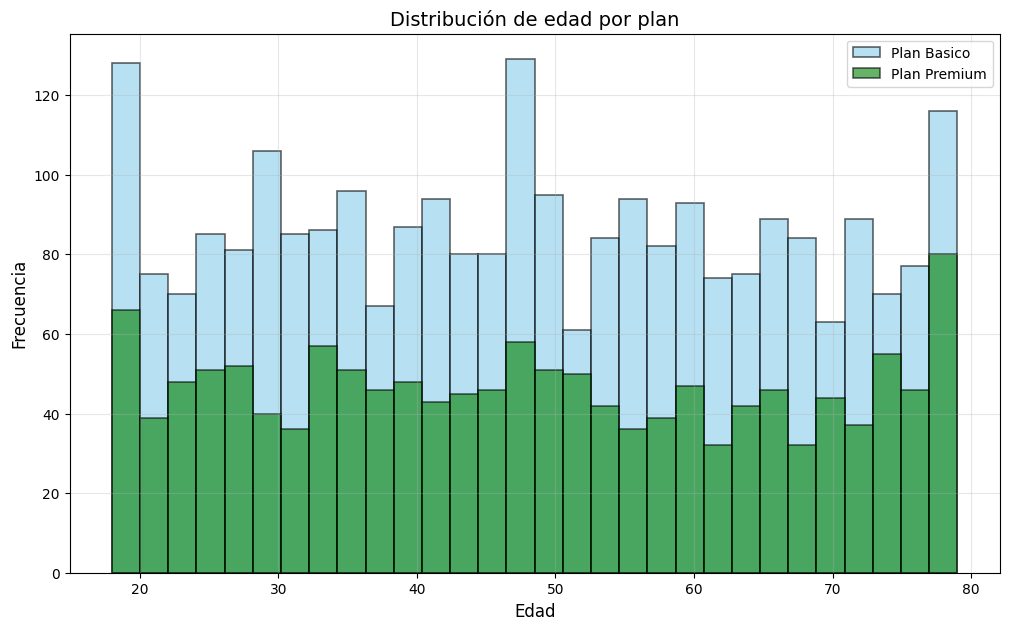

In [ ]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(12, 7))  # Tamaño más grande
for plan, color in zip(user_profile['plan'].unique(), ['skyblue', 'green']):
    subset = user_profile[user_profile['plan'] == plan]['age'].dropna()
    plt.hist(subset, bins=30, alpha=0.6, label=f'Plan {plan}', color=color, edgecolor='black', linewidth=1.2)

plt.title('Distribución de edad por plan', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)  # Grid sutil
plt.show()

💡Insights:
- La distribución de la edad no presenta una forma estrictamente normal; muestra una dispersión relativamente homogénea a lo largo de los rangos etarios, sin concentraciones extremas ni asimetrías marcadas.
- El Plan Básico presenta mayor frecuencia de usuarios en prácticamente todos los rangos etarios, lo que sugiere que es el plan más adoptado independientemente de la edad del cliente.
- El servicio presenta una cobertura etaria amplia, con presencia de usuarios desde edades jóvenes hasta adultos mayores, lo que indica un alcance transversal del producto en distintos segmentos de edad.

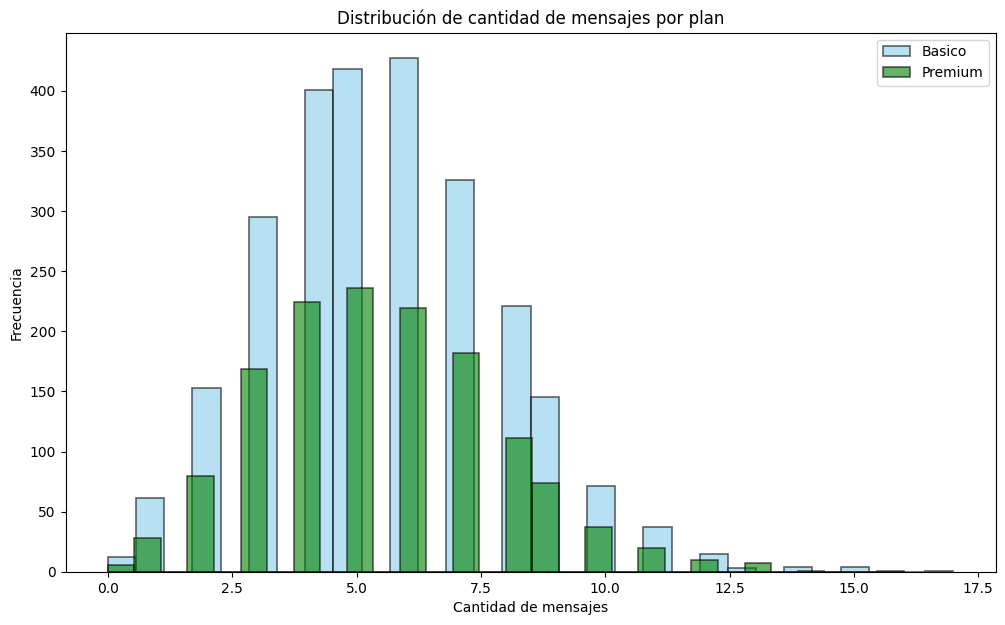

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(12, 7))
for plan, color in zip(user_profile['plan'].unique(), ['skyblue', 'green']):
    subset = user_profile[user_profile['plan'] == plan]['cant_mensajes'].dropna()
    plt.hist(subset, bins=30, alpha=0.6, label=plan, color=color, edgecolor='black', linewidth=1.2)

plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

💡Insights:
- La distribución de la cantidad de mensajes presenta una forma aproximadamente acampanada en ambos planes, con una clara asimetría positiva producto de usuarios con altos volúmenes de mensajes. Esta cola hacia la derecha sugiere la presencia de outliers que elevan el promedio, por lo que la mediana resulta una medida más representativa del comportamiento típico. Asimismo, el Plan Básico predomina en términos de frecuencia absoluta en prácticamente todos los rangos de mensajes, lo que se explica por una mayor cantidad de usuarios en dicho plan.

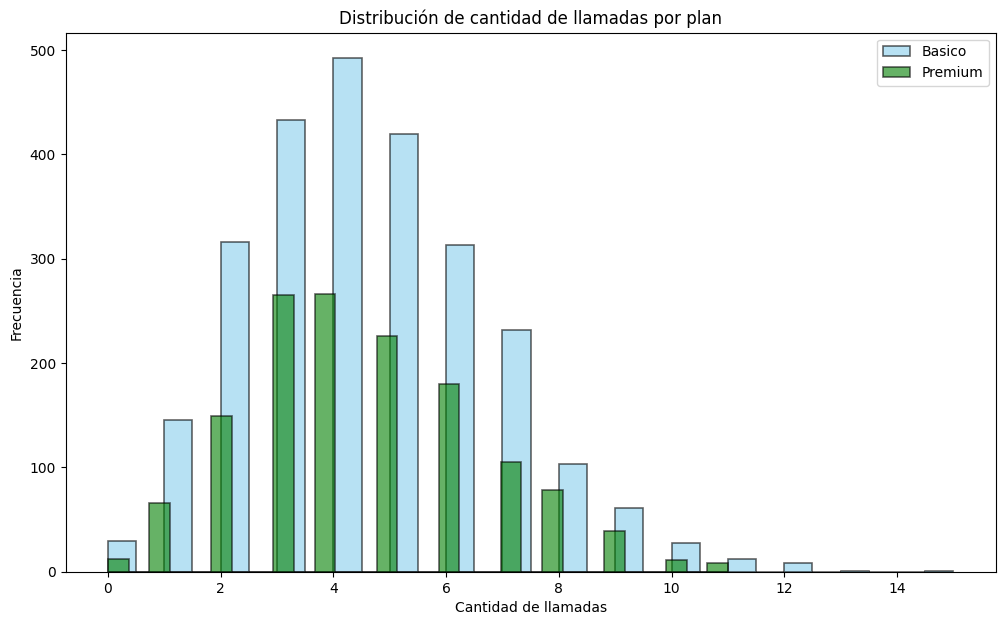

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(12, 7))
for plan, color in zip(user_profile['plan'].unique(), ['skyblue', 'green']):
    subset = user_profile[user_profile['plan'] == plan]['cant_llamadas'].dropna()
    plt.hist(subset, bins=30, alpha=0.6, label=plan, color=color, edgecolor='black', linewidth=1.2)

plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

💡Insights:
- La distribución de la cantidad de llamadas por usuario muestra un comportamiento similar al observado en el uso de mensajes, con un claro predominio del Plan Básico en términos de frecuencia. La forma de la distribución es asimétrica con sesgo a la derecha, lo que indica que la mayoría de los usuarios realiza un número reducido de llamadas, mientras que un grupo minoritario presenta niveles de uso considerablemente más altos. En este contexto, la mediana resulta una medida más representativa del comportamiento típico que el promedio.

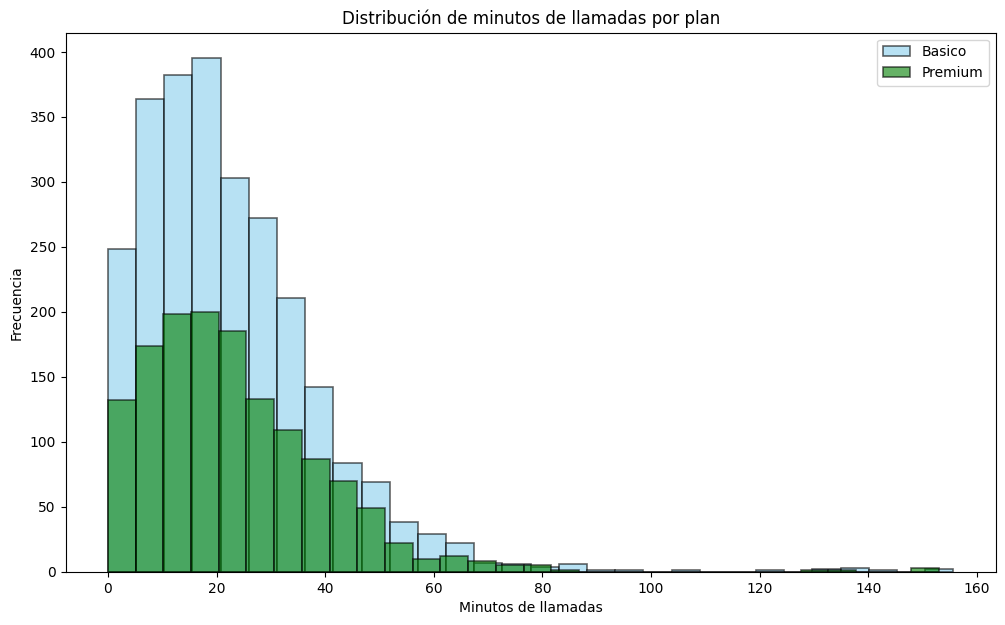

In [ ]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize=(12, 7))
for plan, color in zip(user_profile["plan"].unique(), ["skyblue", "green"]):
    subset = user_profile[user_profile["plan"] == plan]["cant_minutos_llamada"].dropna()
    plt.hist(subset, bins=30, alpha=0.6, label=plan, color=color,edgecolor='black', linewidth=1.2)

plt.title("Distribución de minutos de llamadas por plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

💡Insights:
- La distribución de los minutos de llamadas por usuario muestra un claro predominio del Plan Básico en términos de frecuencia, especialmente en los niveles de consumo bajos y medios. Sin embargo, la distribución se encuentra fuertemente sesgada a la derecha debido a la presencia de usuarios con llamadas de larga duración, principalmente asociados al Plan Premium. Este comportamiento genera una influencia significativa sobre el promedio, por lo que la mediana resulta una medida más representativa del consumo típico de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

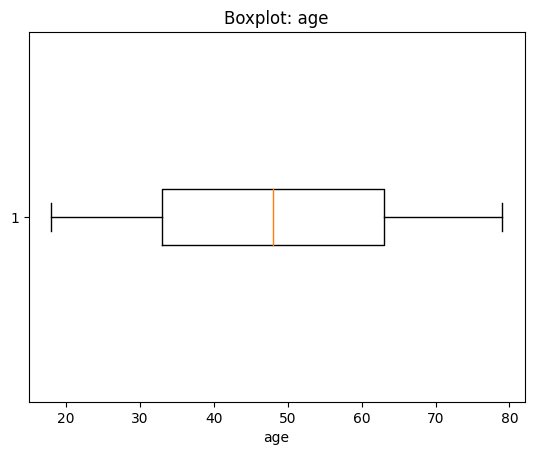

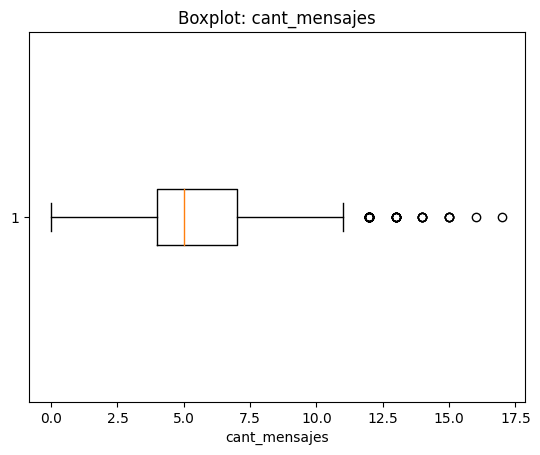

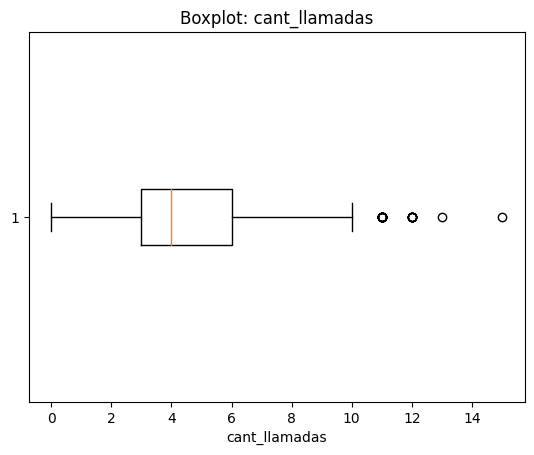

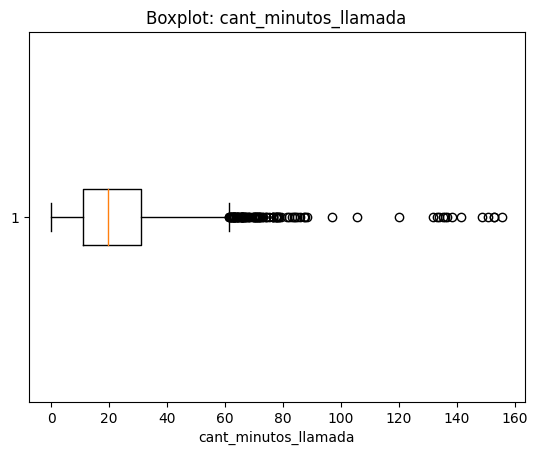

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    plt.figure()
    plt.boxplot(user_profile[col].dropna(), vert=False)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: La variable edad presenta una distribución equilibrada y simétrica. La mediana se sitúa alrededor de los 48 años y el rango intercuartílico (IQR) se extiende aproximadamente entre los 33 y 63 años. No se observan valores fuera de los bigotes bajo el criterio de 1.5×IQR, lo que confirma la ausencia de outliers. Se trata de una variable limpia y confiable para análisis y segmentación demográfica.
- cant_mensajes: La distribución muestra un sesgo positivo (cola a la derecha). La mediana se encuentra en torno a los 5 mensajes, mientras que los valores máximos alcanzan aproximadamente los 17. A partir de los 12 mensajes se identifican outliers claros, correspondientes a usuarios con un uso intensivo del servicio. Este patrón responde a un comportamiento típico de long tail en telecomunicaciones, donde pocos usuarios concentran un consumo elevado.
- cant_llamadas:Presenta una distribución similar a la de mensajes, aunque con un IQR relativamente más amplio en proporción a su escala, indicando mayor variabilidad. La mediana se concentra en valores bajos, y el bigote superior alcanza alrededor de las 10 llamadas. Los valores por encima (11, 12, 13 y 15 llamadas) se consideran outliers, reflejando usuarios con una frecuencia de llamadas significativamente superior al promedio.
- cant_minutos_llamada:Es la variable con mayor asimetría y presencia de outliers. La mediana es baja (aprox. 20 minutos) y el IQR es estrecho, lo que indica que la mayoría de los usuarios realiza llamadas breves. Sin embargo, se observa una acumulación importante de valores atípicos a partir de los 60 minutos, extendiéndose hasta cerca de los 160. Esta cola larga hacia la derecha sugiere la existencia de un segmento diferenciado de usuarios de alto consumo, posiblemente asociados a planes premium o usos corporativos, más que a errores en los datos.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

limites_iqr = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    limites_iqr[col] = limite_superior

    print(f'{col}')
    print(f'  Límite superior IQR: {limite_superior:.2f}')
    print(f'  Máximo observado: {user_profile[col].max():.2f}\n')

cant_mensajes
  Límite superior IQR: 11.50
  Máximo observado: 17.00

cant_llamadas
  Límite superior IQR: 10.50
  Máximo observado: 15.00

cant_minutos_llamada
  Límite superior IQR: 61.32
  Máximo observado: 155.69



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.520380,4.475119,22.831990
std,2.357817,2.142689,16.589736
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.730000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights:

- cant_mensajes:

 ✔ Mantener outliers: Aunque el límite superior IQR es 11.50 y el valor máximo alcanza 17 mensajes, la distancia entre ambos no es extrema. La media (5.52) y la mediana (5) son muy cercanas, lo que indica que estos valores altos no distorsionan significativamente la tendencia central. Los outliers representan usuarios con un uso intensivo pero plausible del servicio, por lo que eliminarlos implicaría perder información relevante sobre patrones reales de consumo.

- cant_llamadas:

 ✔ Mantener outliers: El límite superior IQR se ubica en 10.50, con un máximo observado de 15 llamadas. Si bien existen valores atípicos, la dispersión es moderada (std ≈ 2.14) y la diferencia entre media (4.48) y mediana (4) es baja. Estos casos corresponden a usuarios con mayor frecuencia de llamadas y no evidencian errores de registro, sino un comportamiento de uso válido que puede ser clave para segmentación o análisis de intensidad de consumo.

- cant_minutos_llamada:
  
 ✔ Mantener outliers, con precaución analítica: Esta variable presenta el mayor nivel de asimetría. El límite superior IQR es 61.32 minutos, mientras que el valor máximo alcanza 155.69, muy por encima del rango típico. Aun así, estos valores no deben considerarse ruido: representan un subconjunto reducido de usuarios con tiempos de llamada considerablemente altos. Dado que este comportamiento es coherente con escenarios reales (planes premium, uso corporativo o llamadas prolongadas), se recomienda conservar los outliers, pero considerar transformaciones (logarítmica) o segmentación específica en análisis posteriores para evitar sesgos en modelos agregados.


## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [ ]:
# Crear columna grupo_uso

conditions_uso = [(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)]

choices_uso = ['Bajo uso', 'Uso medio']

# Crear columna grupo_uso
user_profile['grupo_uso'] = np.select(conditions_uso,choices_uso,default='Alto uso')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
conditions_edad = [user_profile['age'] < 30,user_profile['age'] < 60]

choices_edad = ['Joven', 'Adulto']

# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(conditions_edad,choices_edad,default='Adulto Mayor')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

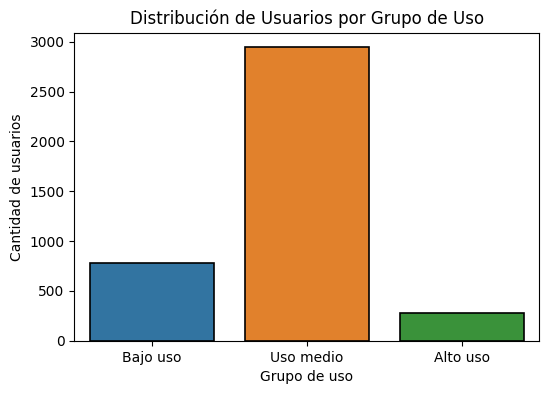

In [ ]:
# Visualización de los segmentos por uso

orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']

plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile,x='grupo_uso',order=orden_uso,edgecolor='black', linewidth=1.2)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

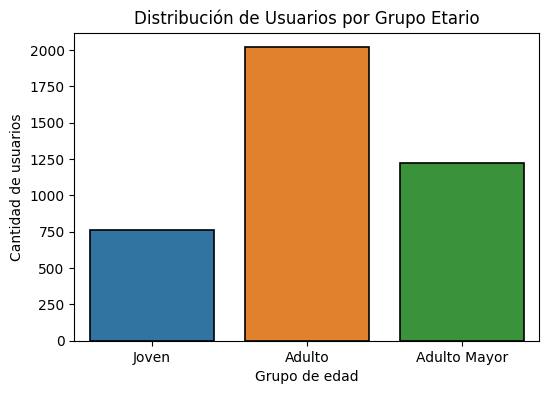

In [ ]:
# Visualización de los segmentos por edad
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']

plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile,x='grupo_edad',order=orden_edad,edgecolor='black', linewidth=1.2)
plt.title('Distribución de Usuarios por Grupo Etario')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna age contenía valores inválidos (por ejemplo, -999), los cuales representaban una proporción menor del total de registros, pero con alto impacto en las métricas descriptivas (promedio y distribución). Estos valores debieron ser tratados como datos faltantes para evitar sesgos en la segmentación por edad.
- Se identificaron inconsistencias en la tabla de uso (usage): algunos registros de llamadas (call) tenían valores en la variable length (mensajes) y algunos registros de mensajes (text) contenían valores en duration. Aunque no representaban la mayoría de los datos, estas filas afectaban la calidad del análisis de uso y fueron depuradas.
- Se detectaron fechas fuera de rango en la columna reg_date, correspondientes a años futuros imposibles al momento de la recolección. Estas filas fueron tratadas como valores nulos para mantener la coherencia temporal del dataset.


🔍 **Segmentos por Edad**
- El segmento Adulto (30–59 años) es el más numeroso y presenta un comportamiento de uso estable y predecible, convirtiéndose en el núcleo principal de la base de clientes.
- El segmento Adulto Mayor (60+ años) tiene una participación relevante, con patrones de uso moderados, lo que sugiere una adopción funcional del servicio más orientada a necesidades básicas.
- El segmento Joven (<30 años) es el menos representativo en volumen, lo que indica una menor penetración del servicio en este grupo etario.


📊 **Segmentos por Nivel de Uso**
- El grupo de Uso Medio concentra la mayor cantidad de usuarios, representando el patrón de consumo típico: uso regular tanto de llamadas como de mensajes sin extremos.
- El segmento de Bajo Uso agrupa a usuarios con consumo mínimo, posiblemente sensibles al precio o con riesgo de abandono.
- El segmento de Alto Uso es minoritario, pero concentra los valores extremos (outliers) en llamadas y mensajes, siendo responsables de gran parte del tráfico total.


➡️ Esto sugiere que el mayor valor para ConnectaTel no proviene de los usuarios extremos, sino de una base amplia de clientes adultos con uso medio, que generan ingresos estables y predecibles. Al mismo tiempo, los usuarios de alto uso representan una oportunidad de monetización adicional, mientras que los de bajo uso requieren estrategias de retención específicas.


💡 **Recomendaciones**
- Optimizar los planes actuales para el segmento Adulto + Uso Medio, priorizando beneficios equilibrados y programas de fidelización, ya que este grupo constituye el corazón del negocio.
- Diseñar planes premium o add-ons específicos para usuarios de Alto Uso, permitiendo capturar mayor valor sin encarecer la oferta general.
- Crear planes simples y de bajo costo para el segmento de Bajo Uso, enfocados en retención y reducción del churn.
- Desarrollar estrategias comerciales diferenciadas por grupo_edad y grupo_uso, utilizando estas variables como base para campañas, promociones y análisis futuros.
- Explorar campañas dirigidas al segmento Joven, con planes más flexibles o digitales, para aumentar su participación en la base de clientes.


---
## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

git clone https://github.com/DayaRodriguezM/telecom-analysis